In [ ]:

import pandas as pd
import gzip
import json
import matplotlib.pyplot as plt



def parse_first_n(path, n=10000000):
    g = gzip.open( path, 'r')
    for i, l in enumerate(g):
        if i >= n:
            break
        yield json.loads(l)


california_reviews = pd.DataFrame(parse_first_n("data/review-California.json.gz"))
california_metadata = pd.DataFrame(parse_first_n("data/meta-California (1).json.gz"))

In [2]:
california_metadata['category_main'] = california_metadata['category'].str[0]
california_metadata

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,category_main
0,City Textile,"City Textile, 3001 E Pico Blvd, Los Angeles, C...",0x80c2c98c0e3c16fd:0x29ec8a728764fdf9,None,34.018891,-118.215290,[Textile exporter],4.5,6,None,None,None,Open now,"[0x80c2c624136ea88b:0xb0315367ed448771, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Textile exporter
1,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,[Korean restaurant],4.4,18,None,"[[Thursday, 6:30AM–6PM], [Friday, 6:30AM–6PM],...","{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Korean restaurant
2,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,[Fabric store],3.3,6,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...","{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store
3,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,[Fabric store],4.3,7,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...",{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store
4,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,[Fabric store],3.5,6,None,"[[Thursday, 8:30AM–5:30PM], [Friday, 8:30AM–5:...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515956,McDonald's,"McDonald's, 1728 Lomita Blvd, Lomita, CA 90717",0x80dd4a7afea27289:0xe49cfab49567e5cb,"Classic, long-running fast-food chain known fo...",33.797530,-118.308527,"[Fast food restaurant, Breakfast restaurant, C...",4.1,830,$,"[[Wednesday, 5AM–12AM], [Thursday, 5AM–12AM], ...","{'Service options': ['Curbside pickup', 'No-co...",NaN,"[0x80dd4a72339feac7:0xcb7398ed660df0b1, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,Fast food restaurant
515957,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,"[Park, Tourist attraction]",4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park
515958,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,[State park],4.8,96,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,State park
515959,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,[Playground],4.3,17,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,Playground


## **Normalized Rating**

In [3]:
#Extract all unique category labels from california_metadata

category_df = california_metadata.copy()
category_df = category_df.explode('category')
#Convert everything to lower case and remove blank space 
category_df['category'] = category_df['category'].str.lower().str.strip()


In [4]:
# # # #Remove tiny categories 
category_counts= category_df.get('category').value_counts()
# Setting threshold for the category 
category_counts.describe()
category_counts_threshold = 35 #median

In [5]:
# Map category_count to each category in the df
category_df['category_count'] = category_df['category'].map(category_counts)
category_df = category_df[category_df.get('category_count') > category_counts_threshold]
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,category_main,category_count
1,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,"[[Thursday, 6:30AM–6PM], [Friday, 6:30AM–6PM],...","{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Korean restaurant,1052.0
2,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...","{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0
3,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...",{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0
4,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,"[[Thursday, 8:30AM–5:30PM], [Friday, 8:30AM–5:...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0
5,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,"[[Thursday, 11AM–9:30PM], [Friday, 11AM–9:30PM...","{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,Restaurant,38523.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515957,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,9636.0
515957,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,10208.0
515958,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,State park,297.0
515959,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,Playground,532.0


In [6]:
# Calculate mean and standard deviation of each category 
category_stats = category_df.groupby("category")['avg_rating'].agg(['mean', 'std']).reset_index()
category_stats.rename(columns= {'mean': 'category_mean', 'std' : 'category_std'})

,category,category_mean,category_std
0,accountant,4.573494,0.705617
1,accounting firm,4.545570,0.670973
2,acupuncture clinic,4.733915,0.476713
3,acupuncturist,4.772840,0.389780
4,acura dealer,4.358182,0.447500
...,...,...,...
2004,youth center,4.398182,0.477451
2005,youth clothing store,4.374118,0.348518
2006,youth organization,4.327103,0.685609
2007,youth social services organization,4.226667,0.625437


In [7]:
# Merge back into category data set
category_df = category_df.merge(category_stats, on='category', how='left')
category_df = category_df.rename(columns={
    'mean': 'category_mean',
    'std': 'category_std'
})
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,category_main,category_count,category_mean,category_std
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,"[[Thursday, 6:30AM–6PM], [Friday, 6:30AM–6PM],...","{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Korean restaurant,1052.0,4.277947,0.326921
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...","{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...",{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,"[[Thursday, 8:30AM–5:30PM], [Friday, 8:30AM–5:...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,"[[Thursday, 11AM–9:30PM], [Friday, 11AM–9:30PM...","{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,Restaurant,38523.0,4.205968,0.422464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,9636.0,4.411571,0.330429
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,10208.0,4.514332,0.285973
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,State park,297.0,4.624242,0.228135
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,Playground,532.0,4.438534,0.4

In [9]:
# Normalized rating
category_df['rating_zscore'] = (
    (category_df['avg_rating'] - category_df['category_mean']) /
    category_df['category_std']
)
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,category_main,category_count,category_mean,category_std,rating_zscore
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,"[[Thursday, 6:30AM–6PM], [Friday, 6:30AM–6PM],...","{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Korean restaurant,1052.0,4.277947,0.326921,0.373341
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...","{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.829601
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...",{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-0.291672
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,"[[Thursday, 8:30AM–5:30PM], [Friday, 8:30AM–5:...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.322015
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,"[[Thursday, 11AM–9:30PM], [Friday, 11AM–9:30PM...","{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,Restaurant,38523.0,4.205968,0.422464,0.695994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,9636.0,4.411571,0.330429,0.872893
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,10208.0,4.514332,0.285973,0.649251
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,State park,297.0,4.624242,0.228135,0.770411
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2e

## **1. How the branding of a business affects reviews?**

In [10]:
####################################################
# Finding a good threshold that consider a brand
####################################################

location_counts = california_metadata.groupby('name')['gmap_id'].nunique()
total_count = california_metadata.get('gmap_id').nunique()

#Calculate proportion for each business
location_proportion = location_counts/total_count

print('Maximum Proportion is:',location_proportion.max())

Maximum Proportion is: 0.005717804705983233


In [11]:
# Create a df that has proportion for each company and filter out brand vs non-brand 
brand_proportion_df = pd.DataFrame()
brand_proportion_df = brand_proportion_df.assign(Proportion = location_proportion)

brand_threshold = location_proportion.quantile(0.95)

brand_proportion_df['is_brand'] = (
    brand_proportion_df['Proportion'] >= brand_threshold
)
# See the count between non-brand vs brand 
brand_proportion_df['is_brand'].value_counts()

is_brand
False    362554
True      23390
Name: count, dtype: int64

In [12]:
brand_proportion_df = brand_proportion_df.reset_index()
brand_proportion_df

,name,Proportion,is_brand
0,"""805"" Auto Details",0.000002,False
1,"""A Heads Up"" Barber Shop",0.000002,False
2,"""Arron Ray Clark Memorial"" Field House",0.000002,False
3,"""Artcentric"" Pottery Painting and Glass Studio",0.000002,False
4,"""BLADE THE BARBER """,0.000002,False
...,...,...,...
385939,🚗 America's Collision Auto Body & Paint,0.000002,False
385940,🚘RG Auto Repairs,0.000002,False
385941,🥇Genesis Window Tint,0.000002,False
385942,🥇Indio Mufflers & Auto Repair,0.000002,False


In [13]:
category_df = category_df.merge(
    brand_proportion_df[['name', 'is_brand']],
    on='name',
    how='left'
)
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,...,MISC,state,relative_results,url,category_main,category_count,category_mean,category_std,rating_zscore,is_brand
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,...,"{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Korean restaurant,1052.0,4.277947,0.326921,0.373341,False
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,...,"{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.829601,False
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,...,{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-0.291672,False
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,...,{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.322015,False
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,...,"{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,Restaurant,38523.0,4.205968,0.422464,0.695994,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,9636.0,4.411571,0.330429,0.872893,False
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,10208.0,4.514332,0.285973,0.649251,False
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,State park,297.0,4.624242,0.228135,0.770411,False
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,Playground,532.0,4.438534,0.408986,-0.338725,False


In [14]:
category_df.groupby('is_brand')['rating_zscore'].mean()


is_brand
False    0.128135
True    -0.189321
Name: rating_zscore, dtype: float64

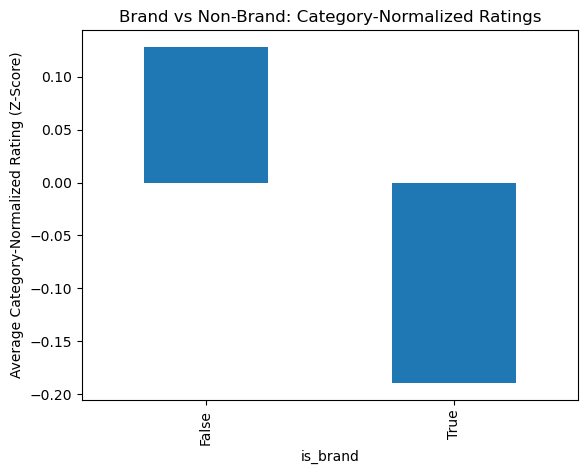

In [15]:

category_df.groupby('is_brand')['rating_zscore'].mean().plot(kind='bar')
plt.ylabel('Average Category-Normalized Rating (Z-Score)')
plt.title('Brand vs Non-Brand: Category-Normalized Ratings')
plt.show()

##### Conclusion: Independent businesses still has higher rate than branded chains.

## **2. In which business categories do independent businesses receive higher customer ratings than branded chains?**

In [16]:
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,...,MISC,state,relative_results,url,category_main,category_count,category_mean,category_std,rating_zscore,is_brand
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,...,"{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Korean restaurant,1052.0,4.277947,0.326921,0.373341,False
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,...,"{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.829601,False
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,...,{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-0.291672,False
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,...,{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.322015,False
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,...,"{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,Restaurant,38523.0,4.205968,0.422464,0.695994,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,9636.0,4.411571,0.330429,0.872893,False
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,10208.0,4.514332,0.285973,0.649251,False
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,State park,297.0,4.624242,0.228135,0.770411,False
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,Playground,532.0,4.438534,0.408986,-0.338725,False


In [ ]:

print('Highest number of review:',category_df.get('num_of_reviews').max())
print('Total number of category:',category_df.groupby('category').count().shape[0])


Highest number of review: 9998
Total number of category: 2009


is_brand,False,True
category_main,,
Air conditioning contractor,0.505537,0.563908
Airline,1.002973,0.551184
Airport,-0.172743,-0.172743
American restaurant,0.487266,0.416832
Amphitheater,-0.472059,0.670901
...,...,...
Vietnamese restaurant,0.742210,0.348458
Visitor center,0.474002,0.299567
Vista point,0.411198,0.495596


In [ ]:
# Setting review number to indetify successful businesses
review_num_threshold = 1000
success_business_normalized = category_df[category_df.get('num_of_reviews') > review_num_threshold]

#Compare rating between non-brand and brand in different category
category_brand_ratings_normalize = (
    success_business_normalized
        .groupby(['category_main', 'is_brand'])['rating_zscore']
        .median()
        .unstack()
)

# Keep only category that has both 
comparable_categories_nomalized = category_brand_ratings_normalize.dropna()
comparable_categories_nomalized

In [ ]:
#Measure who performs better
comparable_categories["compare"] = comparable_categories[False] - comparable_categories[True]

#Identify categories where independents outperform
independent_win = comparable_categories[comparable_categories.get('compare') >0].sort_values(by="compare", ascending=False)
independent_win

##### Top categorical which independent outperform brand

## **3. Which categories are saturated with independents but still highly rated?**
##### *“Saturated” means many independent businesses competing in the same category => has a large number of independent businesses*